# Visuals and telling stories with our data
## Presentation 
Today things will be a bit diffrent for our typicall presentation section. 
- Step 1. As a group find an choose a dataset. (Try looking for a pre-cleaned dataset to save time, on Kaggle when you search for a Dataset, click on filter and select "Clean data")
- Step 2. Look through the data and come up with analytical questions
- Step 3. Discuss with group and pick two questions to answer with plots
- Step 4. Mob program the plots out on one persons computer 
- Step 5. Pick one plot you want to present at the end to the session
- Step 6. Screenshot your graphs and submit on Canvas. 

In [1]:
!pip install pandas numpy seaborn matplotlib 

  Using cached pandas-2.3.3-cp310-cp310-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (91 kB)
  Using cached numpy-2.2.6-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached matplotlib-3.10.8-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (6.3 kB)
  Using cached pillow-12.1.1-cp310-cp310-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metad

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv("ODF_Fire_Data.csv")


In [4]:
df.describe(include="all")

,Serial,FireCategory,FireYear,Area,DistrictName,UnitName,FullFireNumber,FireName,Size_class,EstTotalAcres,...,Industrial_Restriction,Ign_DateTime,ReportDateTime,Discover_DateTime,Control_DateTime,CreationDate,ModifiedDate,DistrictCode,UnitCode,DistFireNumber
count,23490.000000,23490,23490.00000,23490,23490,23490,23490,23490,23490,23411.000000,...,23401,23396,23490,23396,23395,23487,23490,23490.000000,23490.000000,23490
unique,NaN,1,NaN,3,14,31,23335,19637,7,NaN,...,7,20257,22822,22504,22304,11005,22865,NaN,NaN,1009
top,NaN,STAT,NaN,SOA,Southwest Oregon,Grants Pass,02-952017-03,Mill Creek,A,NaN,...,Does Not Apply - Eastern OR,07/15/2018 09:00:00 AM,08/17/2022 05:00:00 PM,08/17/2022 05:00:00 PM,12/31/2013 12:00:00 PM,08/19/2008 12:00:00 AM,10/26/2001 10:20:00 AM,NaN,NaN,018
freq,NaN,23490,NaN,12125,5975,3072,2,33,17013,NaN,...,6562,92,18,19,20,67,12,NaN,NaN,257
mean,90425.933461,NaN,2010.80132,NaN,NaN,NaN,NaN,NaN,NaN,270.802503,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,77.754662,779.371052,NaN
std,20901.016028,NaN,6.73508,NaN,NaN,NaN,NaN,NaN,NaN,6816.736966,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.618857,146.534574,NaN
min,57485.000000,NaN,2000.00000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51.000000,511.000000,NaN
25%,72508.500000,NaN,2005.00000,NaN,NaN,NaN,NaN,NaN,NaN,0.010000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.000000,711.000000,NaN
50%,88340.000000,NaN,2011.00000,NaN,NaN,NaN,NaN,NaN,NaN,0.100000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,73.000000,732.000000,NaN
75%,107432.500000,NaN,2017.00000,NaN,NaN,NaN,NaN,NaN,NaN,0.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,95.000000,954.000000,NaN


In [5]:
df_columns_renamed = df.rename(columns={
     
    "Serial": "serial_id",
    "FireCategory": "fire_category",
    "FireYear": "fire_year",
    "Area": "area_name",
    "DistrictName": "district_name",
    "UnitName": "unit_name",
    "FullFireNumber": "full_fire_number",
    "FireName": "fire_name",
    "EstTotalAcres": "estimated_total_acres",
    "ReportDateTime": "report_datetime",
    "CreationDate": "created_at",
    "ModifiedDate": "modified_at",
    "DistrictCode": "district_code",
    "UnitCode": "unit_code",
    "DistFireNumber": "district_fire_number"
})

df.columns = df_columns_renamed.columns.str.lstrip().str.rstrip().str.replace(' ', '_').str.lower()


In [6]:
df.head()

,serial_id,fire_category,fire_year,area_name,district_name,unit_name,full_fire_number,fire_name,size_class,estimated_total_acres,...,industrial_restriction,ign_datetime,report_datetime,discover_datetime,control_datetime,created_at,modified_at,district_code,unit_code,district_fire_number
0,102649,STAT,2015,EOA,Klamath-Lake,Klamath,15-981082-16,Bass 497,B,3.20,...,Does Not Apply - Eastern OR,09/02/2015 05:00:00 PM,09/02/2015 05:05:00 PM,09/02/2015 05:00:00 PM,09/02/2015 11:00:00 PM,09/05/2015 12:00:00 AM,10/13/2015 08:39:00 AM,98,981,082
1,131239,STAT,2022,EOA,Walker Range - WRFPA,Crescent,22-991220-23,Hay Fire,A,NaN,...,NaN,NaN,08/16/2022 06:56:00 PM,NaN,NaN,08/18/2022 12:00:00 AM,08/18/2022 09:11:00 AM,99,991,220
2,58256,STAT,2000,EOA,Central Oregon,John Day,00-952011-01,Slick Ear #2,B,0.75,...,Does Not Apply - Eastern OR,07/18/2000 07:00:00 PM,07/19/2000 01:20:00 PM,07/19/2000 01:15:00 PM,07/20/2000 12:50:00 AM,07/20/2000 09:13:00 AM,11/14/2000 09:16:00 AM,95,952,011
3,59312,STAT,2000,EOA,Northeast Oregon,La Grande,00-971024-01,Woodley,C,80.00,...,Does Not Apply - Eastern OR,08/24/2000 05:30:00 AM,08/24/2000 01:07:00 PM,08/24/2000 01:07:00 PM,09/01/2000 09:30:00 PM,08/29/2000 03:59:00 PM,12/21/2000 04:22:00 PM,97,971,024
4,61657,STAT,2001,SOA,Southwest Oregon,Grants Pass,01-712133-02,QUEENS BRANCH,A,0.10,...,Lvl 3 Restricted Shutdown,08/10/2001 05:40:00 PM,08/10/2001 05:47:00 PM,08/10/2001 05:45:00 PM,08/10/2001 06:30:00 PM,08/10/2001 06:42:00 PM,08/17/2001 11:45:00 AM,71,712,133


In [7]:
df.isna().sum().sum()

np.int64(16012)

In [8]:
# Fill NaN
df["specificcause"] = df["specificcause"].fillna("unknown")
df["causeby"] = df["causeby"].fillna("unknown")

In [9]:
# Drop NaN
df = df.dropna()
print(df.shape)

(9170, 38)


In [10]:
print(df.isna().sum().sort_values())

serial_id                 0
fire_category             0
fire_year                 0
area_name                 0
district_name             0
unit_name                 0
full_fire_number          0
fire_name                 0
size_class                0
estimated_total_acres     0
protected_acres           0
humanorlightning          0
causeby                   0
generalcause              0
specificcause             0
cause_comments            0
lat_dd                    0
long_dd                   0
latlongdd                 0
fo_landowntype            0
twn                       0
rng                       0
sec                       0
subdiv                    0
landmarklocation          0
county                    0
regusezone                0
reguserestriction         0
industrial_restriction    0
ign_datetime              0
report_datetime           0
discover_datetime         0
control_datetime          0
created_at                0
modified_at               0
district_code       

## Updating Dates

You must convert your dates from strings into datetime objects.  
This allows you to use built-in date methods and perform time-based calculations.


In [11]:
df["ign_datetime"].head(20)
df["discover_datetime"].head(20)
df["control_datetime"].head(20)
df["report_datetime"].head(20)

15     10/26/2008 12:01:00 PM
21     08/17/2009 11:52:00 AM
22     07/15/2009 05:30:00 AM
40     09/25/2016 11:23:00 AM
54     08/03/2019 04:35:00 PM
57     04/29/2020 05:52:00 PM
77     08/05/2007 01:54:00 PM
79     09/01/2007 08:38:00 PM
95     04/24/2009 08:45:00 PM
98     10/04/2007 12:16:00 PM
103    08/15/2008 02:55:00 PM
114    08/24/2009 04:16:00 PM
120    08/06/2008 09:25:00 AM
124    08/01/2009 06:08:00 PM
133    10/11/2008 11:53:00 AM
157    06/03/2009 12:49:00 PM
166    09/04/2008 07:01:00 PM
168    08/08/2008 08:54:00 AM
176    06/28/2009 02:06:00 PM
186    09/14/2007 03:00:00 PM
Name: report_datetime, dtype: object

In [12]:
date_columns = [
    "ign_datetime",
    "discover_datetime",
    "control_datetime",
    "report_datetime"
]

for col in date_columns:
    df[col] = pd.to_datetime(
        df[col],
        format="%m/%d/%Y %I:%M:%S %p",
        errors="coerce"
    )

df[date_columns].dtypes

ign_datetime         datetime64[ns]
discover_datetime    datetime64[ns]
control_datetime     datetime64[ns]
report_datetime      datetime64[ns]
dtype: object

In [13]:
for item in df.columns:
  print(item)

serial_id
fire_category
fire_year
area_name
district_name
unit_name
full_fire_number
fire_name
size_class
estimated_total_acres
protected_acres
humanorlightning
causeby
generalcause
specificcause
cause_comments
lat_dd
long_dd
latlongdd
fo_landowntype
twn
rng
sec
subdiv
landmarklocation
county
regusezone
reguserestriction
industrial_restriction
ign_datetime
report_datetime
discover_datetime
control_datetime
created_at
modified_at
district_code
unit_code
district_fire_number


## What kinds of information can we gain from this data?

In [14]:
df["ign_datetime"].notna().sum()
df["ign_datetime"].head()

15   2008-10-26 11:45:00
21   2009-08-17 11:48:00
22   2009-07-12 19:00:00
40   2016-09-24 23:59:00
54   2019-08-03 16:30:00
Name: ign_datetime, dtype: datetime64[ns]

In [15]:
df = df.dropna(subset=["ign_datetime"])

In [16]:
df["month"] = df["ign_datetime"].dt.month
df["month"]

15       10
21        8
22        7
40        9
54        8
         ..
23481     3
23486     9
23487     6
23488     8
23489     8
Name: month, Length: 9170, dtype: int32

In [17]:
fires_per_month = df.groupby("month").size()
fires_per_month

month
1       27
2       53
3      112
4      340
5      649
6     1194
7     2229
8     2406
9     1368
10     633
11     135
12      24
dtype: int64

## What Makes a Good Visualization

### 1. Select the Right Chart
- **Bar charts:** Great for categorical data.
- **Line charts:** Useful for showing trends over time.
- **Scatter plots:** Show relationships between two variables.
- **Histograms:** Show the frequency or distribution of data.
- **Box plots:** Summarize the distribution of data and help identify outliers.
- **Area charts:** Show changes in quantities over time and emphasize magnitude.

### 2. Simplify and Declutter for Effective Visualization
- Less is usually better. Can someone understand your chart in under 15 seconds?
- Remove gridlines if they do not help with comprehension.
- Avoid unnecessary decorations that do not support your message.
- Use clean, concise labels without overcrowding the chart.
- Clean up axes by removing excessive labels or ticks.

### 3. Use Color Carefully
- Color can highlight important points, but too much color can be confusing.
- Use color to highlight key data.
- Use consistent colors to group related items and help viewers spot trends.

### 4. Tell a Story
- Use titles, labels, and annotations to provide context.
- Highlight key insights to make the data easier to understand.


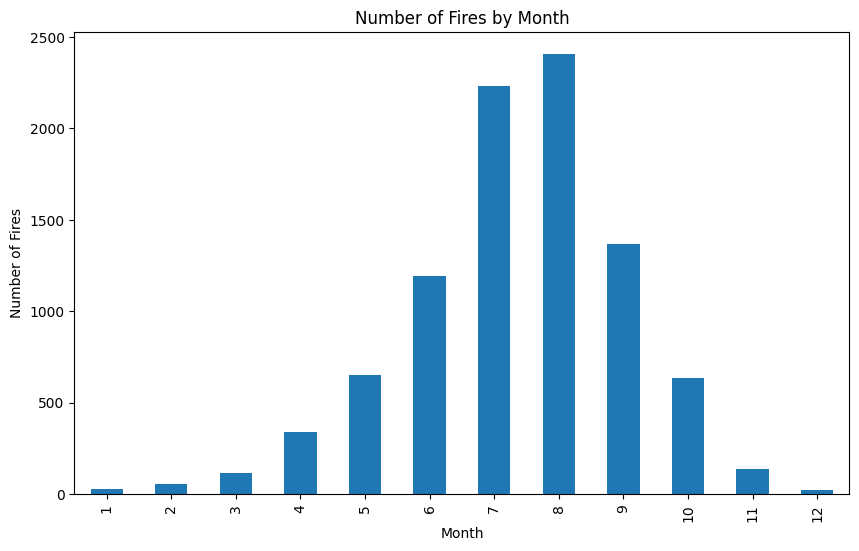

In [ ]:
#Lets make a simple graph 

plt.figure(figsize=(10,6))

fires_per_month.plot(kind="bar")

plt.title("Number of Fires by Month")
plt.xlabel("Month")
plt.ylabel("Number of Fires")

plt.show()

In [19]:
fires_per_month.index

Index([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], dtype='int32', name='month')

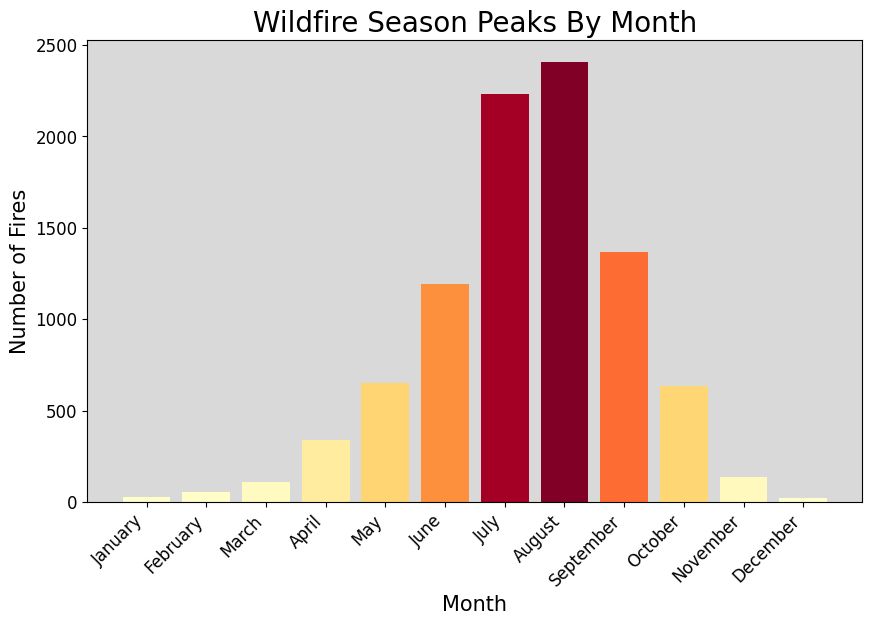

In [20]:
#That chart wasn't great could we use color to improve it?

import matplotlib.pyplot as plt
import calendar
import matplotlib.colors as colors

# Lets start by replacing the month numbers with their names. 
fires_per_month.index = [calendar.month_name[i] for i in fires_per_month.index]

# Lets make a gradent of colors. 
# https://matplotlib.org/stable/gallery/color/named_colors.html
# This will pick our colors between yellow orange and read
cmap = plt.get_cmap("YlOrRd")

# We need to normalize our data to % for the gradent
norm = colors.Normalize(
    vmin=fires_per_month.min(),
    vmax=fires_per_month.max()
)

# Convert values to colors
bar_colors = cmap(norm(fires_per_month.values))

#ax is the object for this chart. plt is for global use 
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot()
# Darker gray background
ax.set_facecolor("#d9d9d9")

# Bar chart
ax.bar(fires_per_month.index, fires_per_month.values, color=bar_colors)

# Titles and labels
ax.set_title("Wildfire Season Peaks By Month", fontsize=20)
ax.set_xlabel("Month", fontsize=15)
ax.set_ylabel("Number of Fires", fontsize=15)

# Tick styling
ax.tick_params(axis="both", labelsize=12)

for label in ax.get_xticklabels():
    label.set_rotation(45)
    label.set_ha("right")

plt.show()


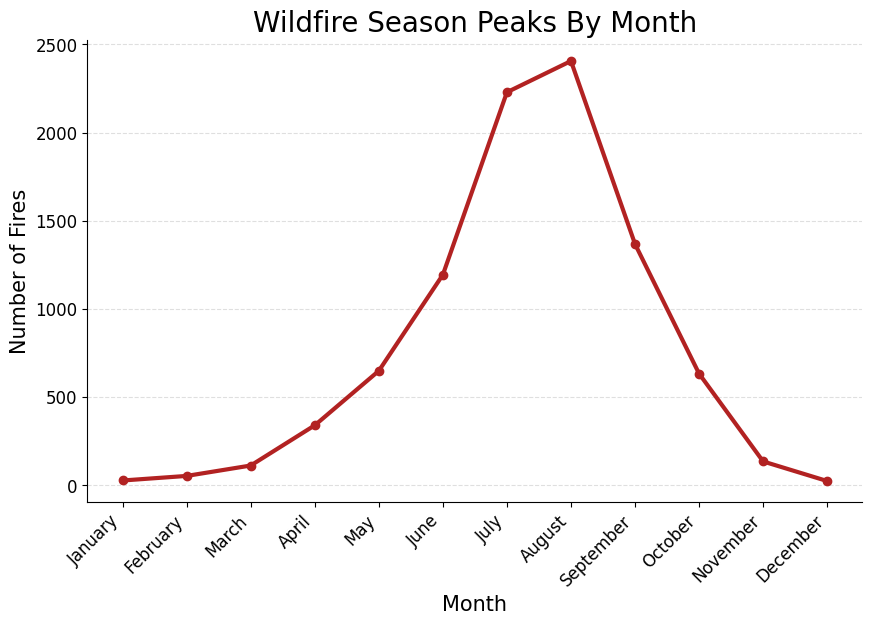

In [21]:
#Maybe that wasn't the right chart lets compaire it with a line chart

fig, ax = plt.subplots(figsize=(10, 6))

# Line plot
ax.plot(
    fires_per_month.index,
    fires_per_month.values,
    marker="o",
    linewidth=3,
    color="firebrick"
)

# Titles and labels
ax.set_title("Wildfire Season Peaks By Month", fontsize=20)
ax.set_xlabel("Month", fontsize=15)
ax.set_ylabel("Number of Fires", fontsize=15)

# Tick styling
ax.tick_params(axis="both", labelsize=12)
for label in ax.get_xticklabels():
    label.set_rotation(45)
    label.set_ha("right")

# Remove top and right boarders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Removing the veritical lines 
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

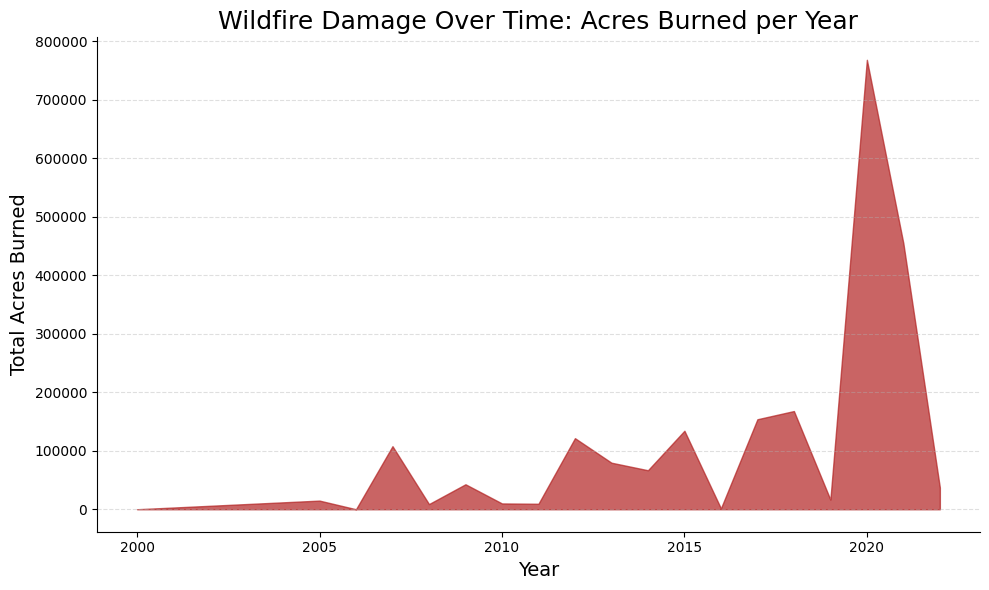

In [34]:
#Area chart
#Group and calculate the total acres_per_year
acres_per_year = df.groupby("fire_year")["estimated_total_acres"].sum()

fig, ax = plt.subplots(figsize=(10,6))

# adding the fill for the aria chart
ax.fill_between(
    acres_per_year.index,
    acres_per_year.values,
    color="firebrick",
    alpha=0.7
)

# Titles and labels
ax.set_title("Wildfire Damage Over Time: Acres Burned per Year", fontsize=18)
ax.set_xlabel("Year", fontsize=14)
ax.set_ylabel("Total Acres Burned", fontsize=14)


# Light horizontal gridlines
ax.grid(axis="y", linestyle="--", alpha=0.4)

# Clean up borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

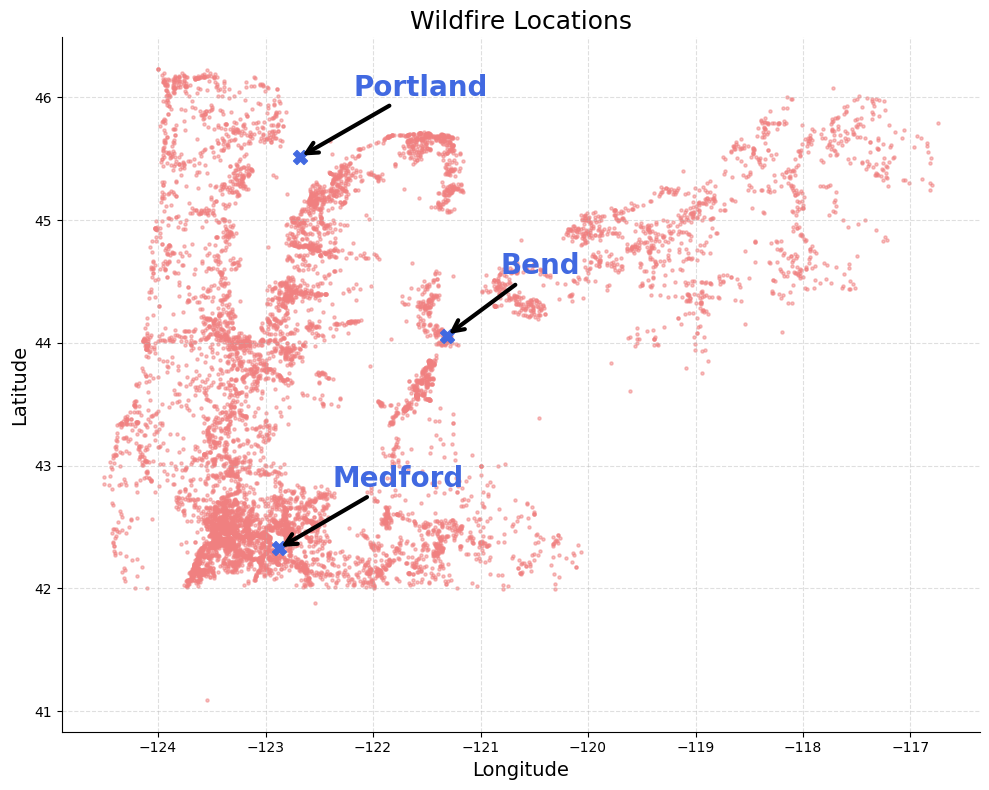

In [ ]:

location_data = df.dropna(subset=["lat_dd", "long_dd"])

fig, ax = plt.subplots(figsize=(10,8))

cities = {
    "Portland": (-122.6784, 45.5152),
    "Bend": (-121.3153, 44.0582),
    "Medford": (-122.8756, 42.3265)
}


ax.scatter(
    location_data["long_dd"],
    location_data["lat_dd"],
    s=5,              # point size
    alpha=0.5,
    color="lightcoral"
)

for city, (lon, lat) in cities.items():
    ax.scatter(lon, lat, color="royalblue", s=100, marker="X")
    # https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.annotate.html
    ax.annotate(
        city,
        xy=(lon, lat),
        xytext=(lon + 0.5, lat + 0.5),
        arrowprops=dict(arrowstyle="->", lw=3, mutation_scale=20),
        fontsize=20,
        color="royalblue",
        fontweight="bold"
    )


ax.set_title("Wildfire Locations", fontsize=18)
ax.set_xlabel("Longitude", fontsize=14)
ax.set_ylabel("Latitude", fontsize=14)

ax.grid(linestyle="--", alpha=0.4)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# Your Turn: 
- Step 1. As a group find an choose a new dataset.
- Step 2. Look through the data and come up with analytical questions
- Step 3. Discuss with group and pick two questions to answer with plots
- Step 4. Mob program the plots out on one persons computer 
- Step 5. Pick one plot you want to present at the end to the session

Work with your group to mob program the plots and be prepared to share them with the class.